In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import re
import missingno as msno
import umap

In [2]:
Path.cwd()
PROJECT_ROOT = Path.cwd().parents[1]
DATA_PATH = PROJECT_ROOT / "data" / "final_dataset" / "main_dataset.csv"
df = pd.read_csv(DATA_PATH)
df.shape

(13077, 76)

In [44]:
df["province"].value_counts()

KeyError: 'province'

In [3]:

def clean_column_name(col: str) -> str:
    col = col.strip().lower()
    
    # Replace common separators with underscore
    col = col.replace(" ", "_")
    col = col.replace("-", "_")
    col = col.replace("/", "_")
    
    # Remove parentheses and commas
    col = re.sub(r"[(),]", "", col)
    
    # Remove any character that is not alphanumeric or underscore
    col = re.sub(r"[^a-z0-9_]", "", col)
    
    # Collapse multiple underscores
    col = re.sub(r"_+", "_", col)
    
    # Remove leading/trailing underscores
    col = col.strip("_")
    
    return col

df.columns = [clean_column_name(c) for c in df.columns]

df.columns.tolist()

['fsa',
 'n_days',
 'concentration',
 'longitude',
 'latitude',
 'pct_single_detached',
 'pct_highrise',
 'pct_other_attached',
 'pct_movable',
 'avg_rooms',
 'pct_major_repair',
 'pct_pre_1980',
 'pct_1981_2000',
 'pct_post_2001',
 'median_home_value',
 'pop_2016',
 'num_dwellings',
 'occ_dwellings',
 'median_age',
 'avg_household_size',
 'pct_owned',
 'pct_rented',
 'pct_band',
 'pct_low_income',
 'med_income',
 'pct_high_income',
 'pct_govt_transfers',
 'unemployment_rate',
 'pct_non_laborer',
 'pct_bachelor_plus',
 'pct_overcrowded',
 'pct_unsuitable_housing',
 'pct_housing_poor_owners',
 'rxtp_intrusive_rocks',
 'rxtp_metamorphic_rocks',
 'rxtp_sedimentary_and_volcanic_rocks',
 'rxtp_sedimentary_rocks',
 'rxtp_unknown',
 'rxtp_volcanic_rocks',
 'geolprov_appalachian_orogen',
 'geolprov_arctic_continental_shelf',
 'geolprov_arctic_platform',
 'geolprov_atlantic_continental_shelf',
 'geolprov_bear_province',
 'geolprov_churchill_province',
 'geolprov_cordilleran_orogen',
 'geolprov_

In [22]:
print("Rows:", len(df), "Columns:", df.shape[1])
display(df.head(3))
display(df.describe().T)

Rows: 13077 Columns: 80


,fsa,n_days,concentration,longitude,latitude,pct_single_detached,pct_highrise,pct_other_attached,pct_movable,avg_rooms,...,volcanic_deposits,weathered_bedrock_or_regolith,average_heating_days,mean_uranium,max_uranium,provinceterritory,log_radon,PC1,PC2,PC3
0,A0A,127.0,20.0,-53.087800,47.317160,0.923057,0.000257,0.071024,0.005661,7.0,...,0.0,0.0,305.532585,NaN,NaN,NL,2.995732,1.454114,0.369617,-0.945482
1,A0A,108.0,36.0,-53.087800,47.317160,0.923057,0.000257,0.071024,0.005661,7.0,...,0.0,0.0,305.532585,NaN,NaN,NL,3.583519,1.454114,0.369617,-0.945482
2,A0E,91.0,7.5,-54.777629,47.384855,0.933854,0.000521,0.055208,0.010417,6.9,...,0.0,0.0,326.720975,0.637329,3.509083,NL,2.014903,1.017081,1.480669,-0.940200


,count,mean,std,min,25%,50%,75%,max
n_days,13077.0,9.671316e+01,14.693980,30.000000,91.000000,92.000000,98.000000,456.000000
concentration,13077.0,9.644464e+01,168.876977,7.500000,19.000000,48.000000,115.000000,5657.000000
longitude,13077.0,-8.896949e+01,20.852532,-130.249226,-106.501972,-81.273475,-73.431230,-52.732052
latitude,13077.0,4.857089e+01,4.071372,41.930362,45.281341,48.591134,50.994356,58.387355
pct_single_detached,13077.0,7.281721e-01,0.161337,0.002543,0.633413,0.757714,0.857659,1.000000
...,...,...,...,...,...,...,...,...
max_uranium,9956.0,2.603828e+00,4.081620,-0.360973,1.140218,1.768948,2.770474,34.915615
log_radon,13077.0,3.836296e+00,1.223411,2.014903,2.944439,3.871201,4.744932,8.640649
PC1,13077.0,0.000000e+00,1.676644,-8.353295,-0.908433,0.384537,1.265680,4.418959
PC2,13077.0,-3.477459e-17,1.537098,-5.878245,-0.710157,0.343138,1.017425,3.201057


In [23]:
df[structural_cols].isna().sum().sort_values(ascending=False)

pct_single_detached    0
pct_highrise           0
pct_other_attached     0
pct_movable            0
avg_rooms              0
pct_major_repair       0
pct_pre_1980           0
pct_1981_2000          0
pct_post_2001          0
dtype: int64

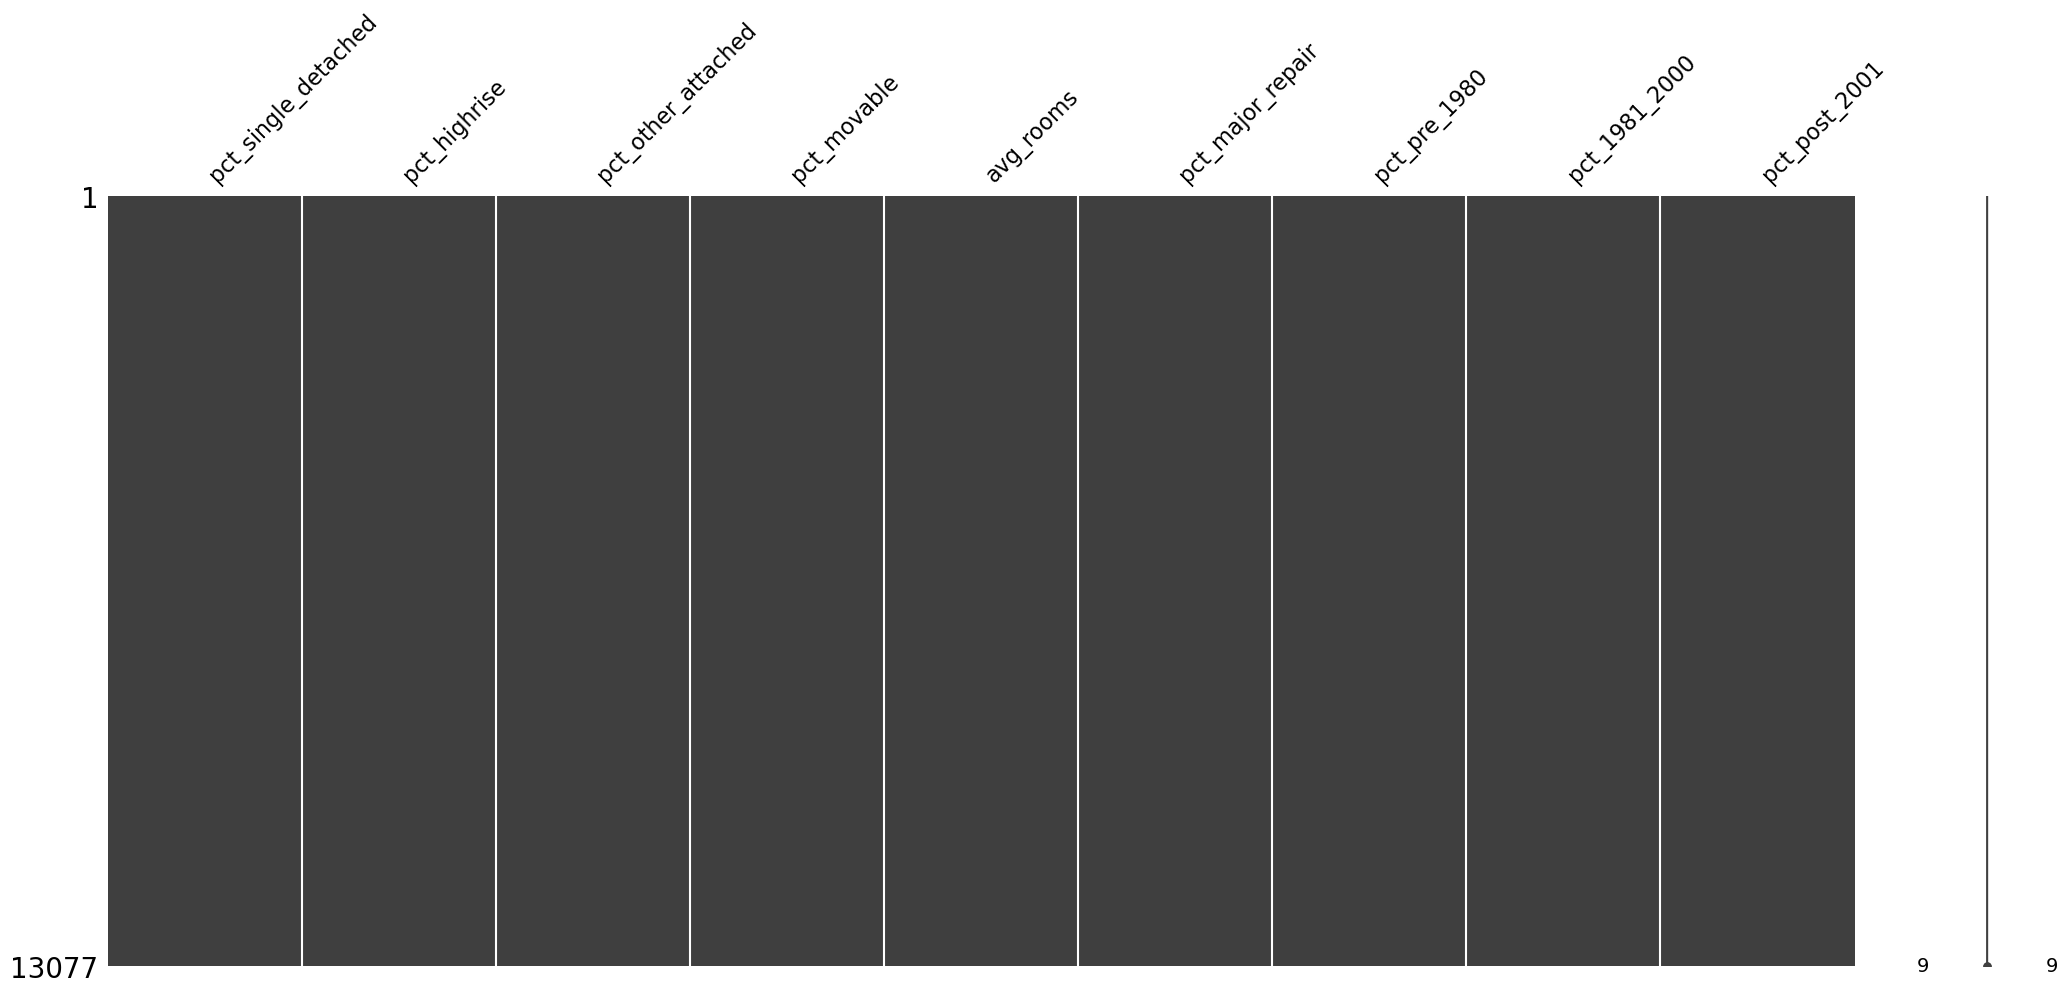

In [25]:
msno.matrix(df[structural_cols])
plt.show()

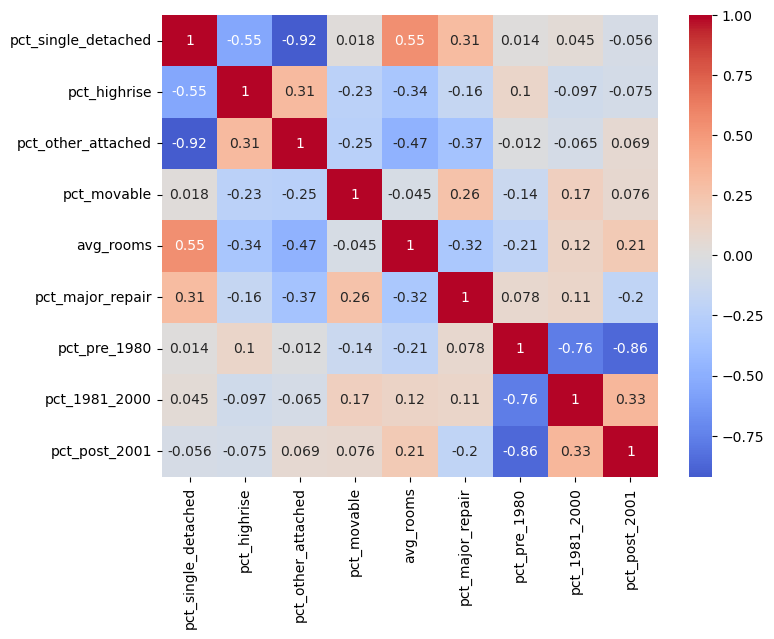

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[structural_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.show()

Trivial:  housing types are anti-correlated,  
avg_rooms correlated with one-family homes, 
pct_major_repair -corr with new homes,
trailer homes corr with pct_major_repair,
 

In [34]:
corr = df[structural_cols].corr()

# Mask for upper triangle (excluding diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

upper_triangle = corr.where(mask)

pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

pairs.columns = ["feature_1", "feature_2", "correlation"]

# Filter by |r| > 0.3
strong_pairs = pairs[
    pairs["correlation"].abs() > 0.3
].sort_values(by="correlation", key=lambda x: x.abs(), ascending=False)

strong_pairs

,feature_1,feature_2,correlation
2,pct_single_detached,pct_other_attached,-0.922378
62,pct_pre_1980,pct_post_2001,-0.862991
61,pct_pre_1980,pct_1981_2000,-0.764944
1,pct_single_detached,pct_highrise,-0.554357
4,pct_single_detached,avg_rooms,0.548961
22,pct_other_attached,avg_rooms,-0.474836
23,pct_other_attached,pct_major_repair,-0.365327
13,pct_highrise,avg_rooms,-0.341464
71,pct_1981_2000,pct_post_2001,0.334730
41,avg_rooms,pct_major_repair,-0.321807


In [35]:
for _, row in strong_pairs.iterrows():
    print(f"{row.feature_1}  <->  {row.feature_2}  :  {row.correlation:.3f}")

pct_single_detached  <->  pct_other_attached  :  -0.922
pct_pre_1980  <->  pct_post_2001  :  -0.863
pct_pre_1980  <->  pct_1981_2000  :  -0.765
pct_single_detached  <->  pct_highrise  :  -0.554
pct_single_detached  <->  avg_rooms  :  0.549
pct_other_attached  <->  avg_rooms  :  -0.475
pct_other_attached  <->  pct_major_repair  :  -0.365
pct_highrise  <->  avg_rooms  :  -0.341
pct_1981_2000  <->  pct_post_2001  :  0.335
avg_rooms  <->  pct_major_repair  :  -0.322
pct_highrise  <->  pct_other_attached  :  0.311
pct_single_detached  <->  pct_major_repair  :  0.307


Type of building is strongly correlated, as is age of housing stock. 

There are a bunch of variables here that are pretty highly correlated.  
We could consider reducing dimensionality here by replacing type of housing with 'urbanicity'. 
 
pct_single_detached  <->  pct_other_attached  :  -0.922
pct_single_detached  <->  pct_highrise  :  -0.554
pct_highrise  <->  pct_other_attached  :  0.311

The housing age data is also pretty degenerate:
pct_pre_1980  <->  pct_post_2001  :  -0.863
pct_pre_1980  <->  pct_1981_2000  :  -0.765

Average number of rooms is correlated with single family homes,
and anti-corr with apartments:
pct_single_detached  <->  avg_rooms  :  0.549
pct_other_attached  <->  avg_rooms  :  -0.475
pct_highrise  <->  avg_rooms  :  -0.341

Repair decreases with room but increases with single-family home:
avg_rooms  <->  pct_major_repair  :  -0.322
pct_single_detached  <->  pct_major_repair  :  0.307

SEEMS LIKE WE MIGHT BE ABLE TO REDUCE THE VARIABLES HERE





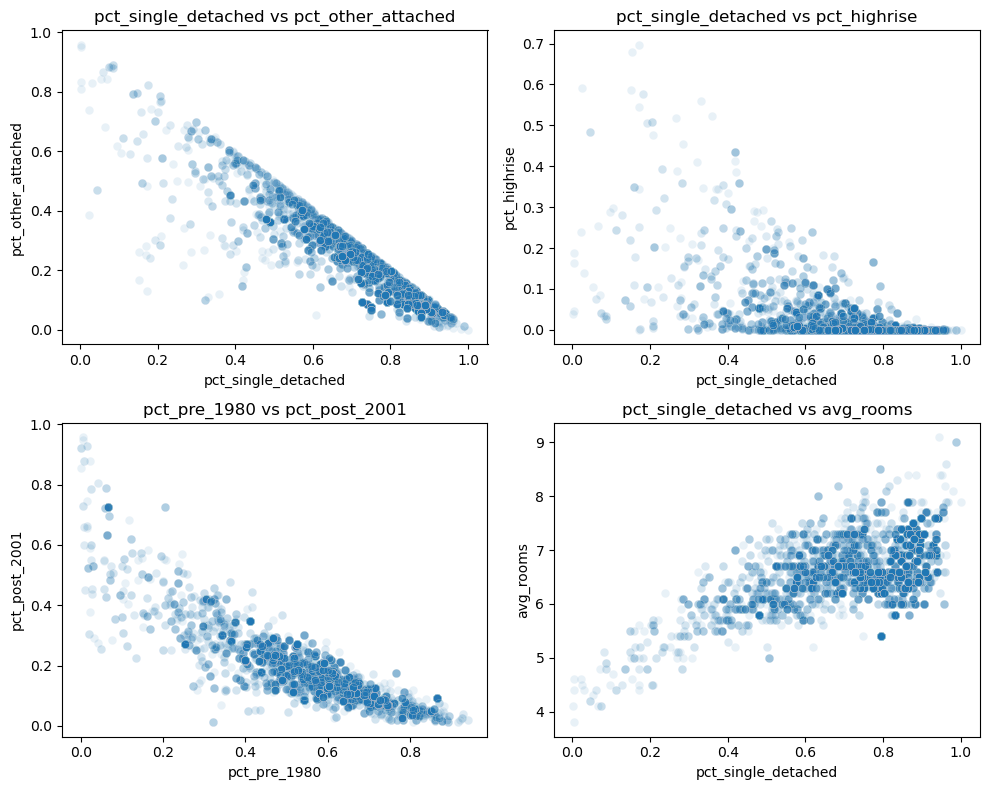

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

pairs_to_plot = [
    ("pct_single_detached", "pct_other_attached"),
    ("pct_single_detached", "pct_highrise"),
    ("pct_pre_1980", "pct_post_2001"),
    ("pct_single_detached", "avg_rooms"),
]

for i, (xcol, ycol) in enumerate(pairs_to_plot):
    sns.scatterplot(
        data=df,
        x=xcol,
        y=ycol,
        alpha=0.05,  # lower alpha to reveal density
        ax=axes[i]
    )
    axes[i].set_title(f"{xcol} vs {ycol}")

plt.tight_layout()
plt.show()

In [42]:
strong_pairs_05 = strong_pairs[
    strong_pairs["correlation"].abs() > 0.3
]

strong_pairs_05

,feature_1,feature_2,correlation
2,pct_single_detached,pct_other_attached,-0.922378
62,pct_pre_1980,pct_post_2001,-0.862991
61,pct_pre_1980,pct_1981_2000,-0.764944
1,pct_single_detached,pct_highrise,-0.554357
4,pct_single_detached,avg_rooms,0.548961
22,pct_other_attached,avg_rooms,-0.474836
23,pct_other_attached,pct_major_repair,-0.365327
13,pct_highrise,avg_rooms,-0.341464
71,pct_1981_2000,pct_post_2001,0.334730
41,avg_rooms,pct_major_repair,-0.321807


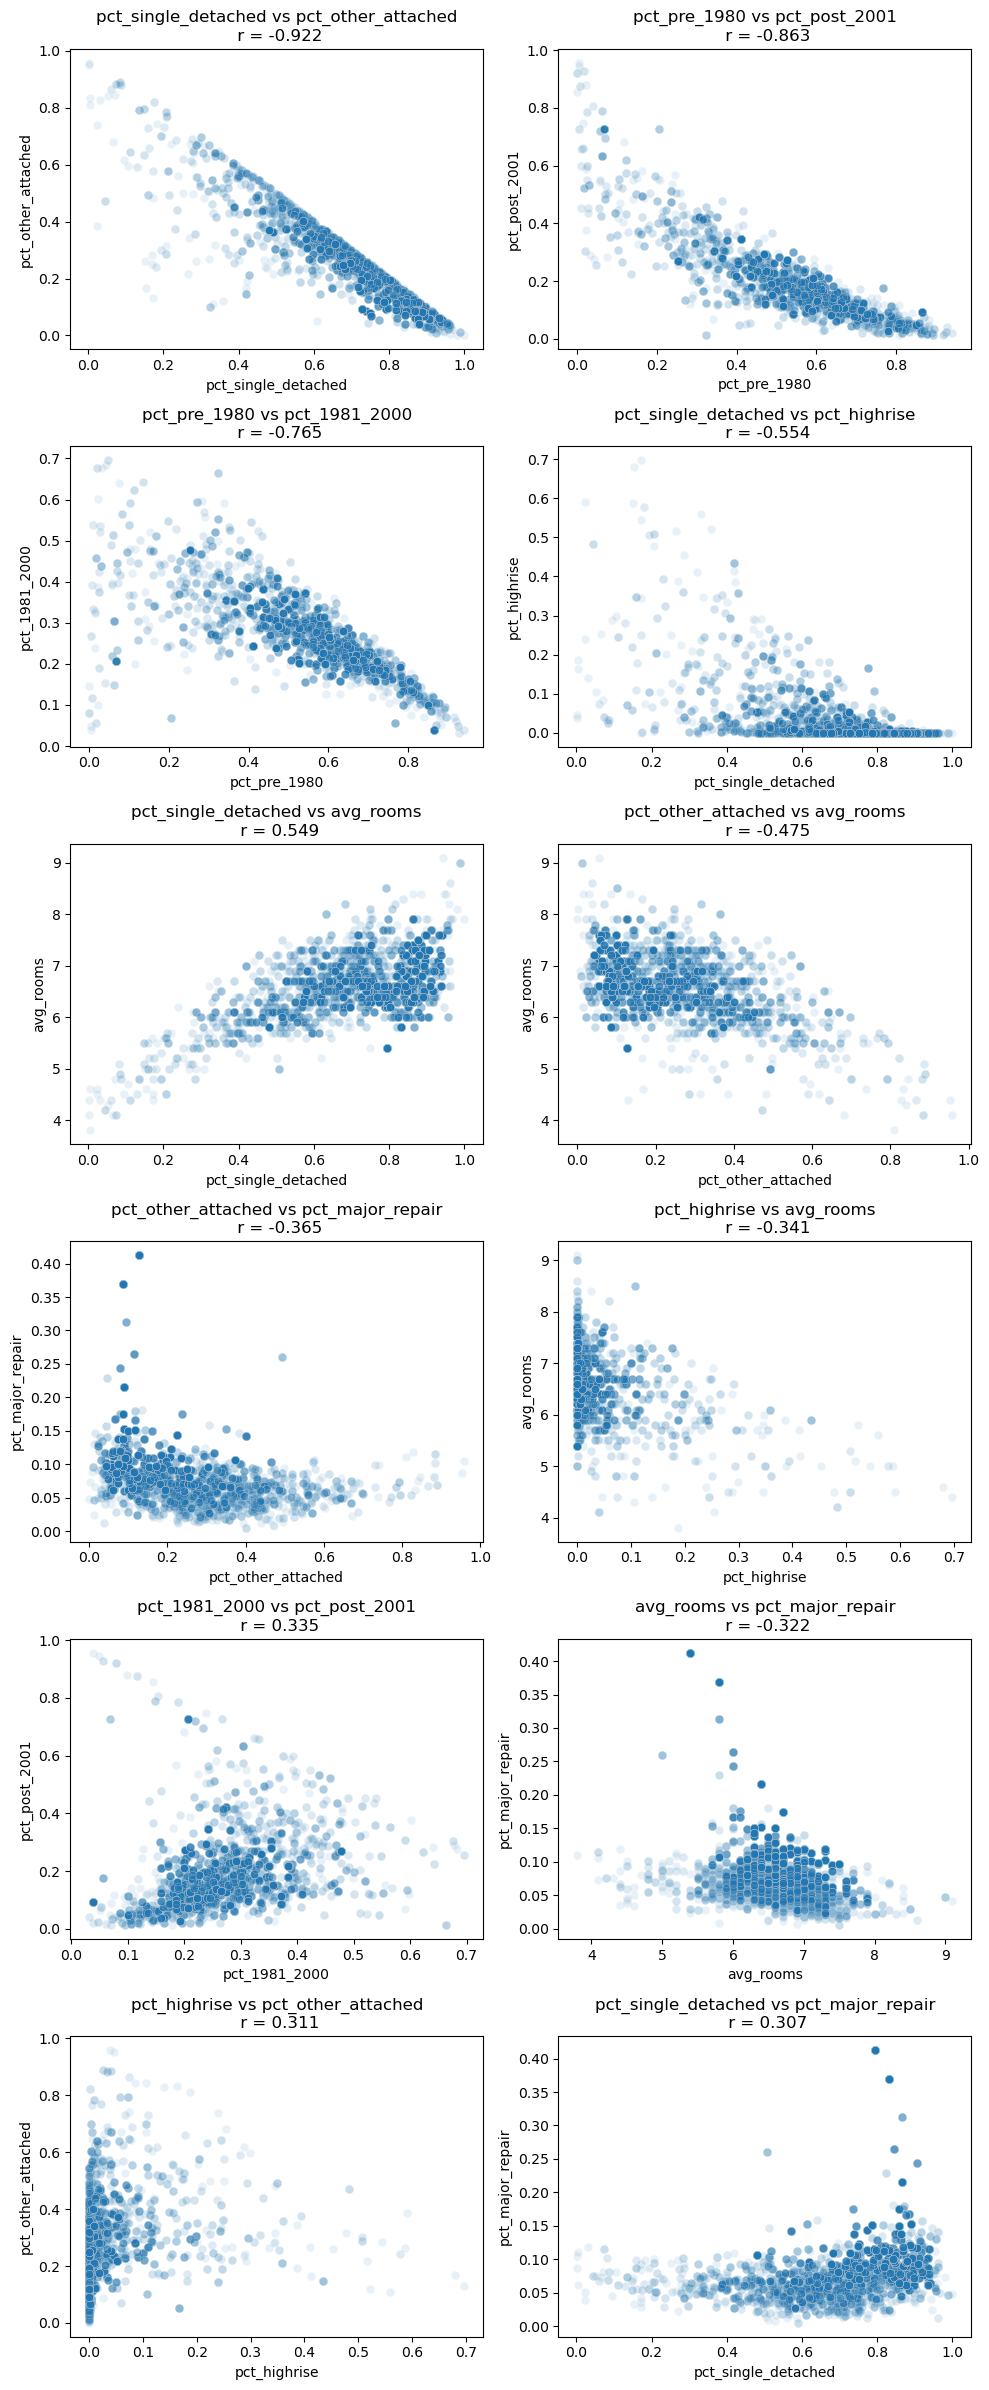

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

pairs_list = list(zip(
    strong_pairs_05["feature_1"],
    strong_pairs_05["feature_2"]
))

n = len(pairs_list)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4*nrows))
axes = axes.flatten()

for i, (xcol, ycol) in enumerate(pairs_list):
    sns.scatterplot(
        data=df,
        x=xcol,
        y=ycol,
        alpha=0.05,  # low alpha helps reveal density
        ax=axes[i]
    )
    r_val = strong_pairs_05.iloc[i]["correlation"]
    axes[i].set_title(f"{xcol} vs {ycol}\n r = {r_val:.3f}")

# Remove unused subplot axes if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

not sure what to do about housing age and other proportions. But you can clearly see the effect: when one of them starts to get large, the other thiing is negatively correlated!

c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


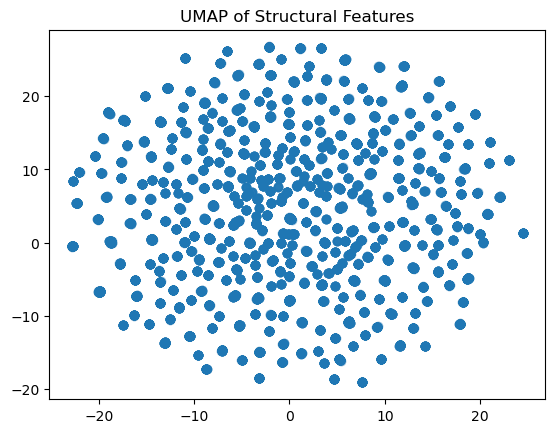

In [37]:
import umap


X = df[structural_cols]
X_scaled = StandardScaler().fit_transform(X)

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X_scaled)

plt.scatter(embedding[:,0], embedding[:,1], alpha=0.5)
plt.title("UMAP of Structural Features")
plt.show()

This UMAP shows there are not distinct groups of housing. They vary continuously.

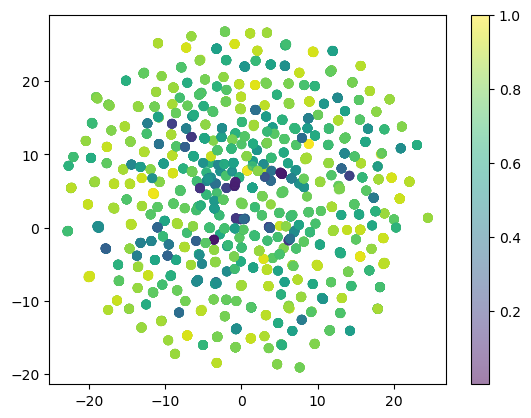

In [38]:
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=df["pct_single_detached"],
    cmap="viridis",
    alpha=0.5
)
plt.colorbar()

In [27]:
corrs = df[structural_cols + ["log_radon"]].corr()

corrs["log_radon"].sort_values(ascending=False)

log_radon              1.000000
pct_single_detached    0.193629
avg_rooms              0.112562
pct_movable            0.076980
pct_major_repair       0.072532
pct_pre_1980           0.051371
pct_post_2001         -0.020343
pct_1981_2000         -0.069880
pct_highrise          -0.082520
pct_other_attached    -0.211266
Name: log_radon, dtype: float64

In [28]:
df["log_radon"] = np.log(df["concentration"])

In [29]:
corr_matrix = df[structural_cols + ["log_radon"]].corr()

radon_corr = corr_matrix["log_radon"].drop("log_radon")
radon_corr_sorted = radon_corr.reindex(
    radon_corr.abs().sort_values(ascending=False).index
)

radon_corr_sorted

pct_other_attached    -0.211266
pct_single_detached    0.193629
avg_rooms              0.112562
pct_highrise          -0.082520
pct_movable            0.076980
pct_major_repair       0.072532
pct_1981_2000         -0.069880
pct_pre_1980           0.051371
pct_post_2001         -0.020343
Name: log_radon, dtype: float64

In [32]:
top_k = 10
top_features = radon_corr_sorted.index[:top_k]

top_features

Index(['pct_other_attached', 'pct_single_detached', 'avg_rooms',
       'pct_highrise', 'pct_movable', 'pct_major_repair', 'pct_1981_2000',
       'pct_pre_1980', 'pct_post_2001'],
      dtype='str')

IndexError: index 4 is out of bounds for axis 0 with size 4

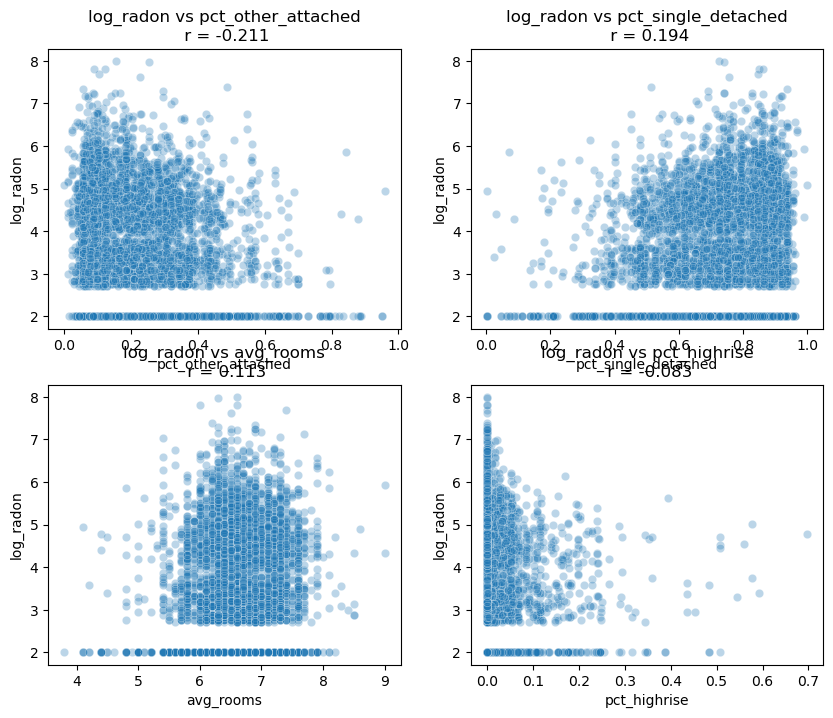

In [33]:

sample_df = df.sample(5000, random_state=1)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.scatterplot(
        data=sample_df,
        x=col,
        y="log_radon",
        alpha=0.3,
        ax=axes[i]
    )
    axes[i].set_title(f"log_radon vs {col}\n r = {radon_corr_sorted[col]:.3f}")

plt.tight_layout()
plt.show()

In [4]:
df["log_radon"] = np.log(df["concentration"])

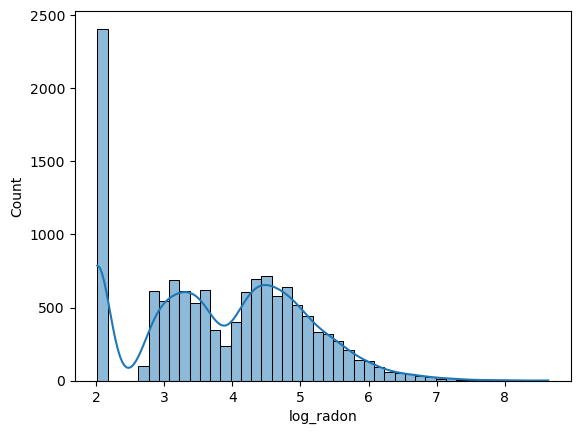

In [5]:

sns.histplot(df["log_radon"], kde=True)
plt.show()

In [6]:
structural_cols = [
    "pct_single_detached",
    "pct_highrise",
    "pct_other_attached",
    "pct_movable",
    "avg_rooms",
    "pct_major_repair",
    "pct_pre_1980",
    "pct_1981_2000",
    "pct_post_2001",
]

In [7]:
df[[
    "pct_single_detached",
    "pct_highrise",
    "pct_other_attached",
    "pct_movable"
]].sum(axis=1).describe()

count    1.307700e+04
mean     1.000000e+00
std      1.297990e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [21]:
print("Rows:", len(df), "Columns:", df.shape[1])
display(df.head(3))
display(df.describe().T)

Rows: 13077 Columns: 80


,fsa,n_days,concentration,longitude,latitude,pct_single_detached,pct_highrise,pct_other_attached,pct_movable,avg_rooms,...,volcanic_deposits,weathered_bedrock_or_regolith,average_heating_days,mean_uranium,max_uranium,provinceterritory,log_radon,PC1,PC2,PC3
0,A0A,127.0,20.0,-53.087800,47.317160,0.923057,0.000257,0.071024,0.005661,7.0,...,0.0,0.0,305.532585,NaN,NaN,NL,2.995732,1.454114,0.369617,-0.945482
1,A0A,108.0,36.0,-53.087800,47.317160,0.923057,0.000257,0.071024,0.005661,7.0,...,0.0,0.0,305.532585,NaN,NaN,NL,3.583519,1.454114,0.369617,-0.945482
2,A0E,91.0,7.5,-54.777629,47.384855,0.933854,0.000521,0.055208,0.010417,6.9,...,0.0,0.0,326.720975,0.637329,3.509083,NL,2.014903,1.017081,1.480669,-0.940200


,count,mean,std,min,25%,50%,75%,max
n_days,13077.0,9.671316e+01,14.693980,30.000000,91.000000,92.000000,98.000000,456.000000
concentration,13077.0,9.644464e+01,168.876977,7.500000,19.000000,48.000000,115.000000,5657.000000
longitude,13077.0,-8.896949e+01,20.852532,-130.249226,-106.501972,-81.273475,-73.431230,-52.732052
latitude,13077.0,4.857089e+01,4.071372,41.930362,45.281341,48.591134,50.994356,58.387355
pct_single_detached,13077.0,7.281721e-01,0.161337,0.002543,0.633413,0.757714,0.857659,1.000000
...,...,...,...,...,...,...,...,...
max_uranium,9956.0,2.603828e+00,4.081620,-0.360973,1.140218,1.768948,2.770474,34.915615
log_radon,13077.0,3.836296e+00,1.223411,2.014903,2.944439,3.871201,4.744932,8.640649
PC1,13077.0,0.000000e+00,1.676644,-8.353295,-0.908433,0.384537,1.265680,4.418959
PC2,13077.0,-3.477459e-17,1.537098,-5.878245,-0.710157,0.343138,1.017425,3.201057


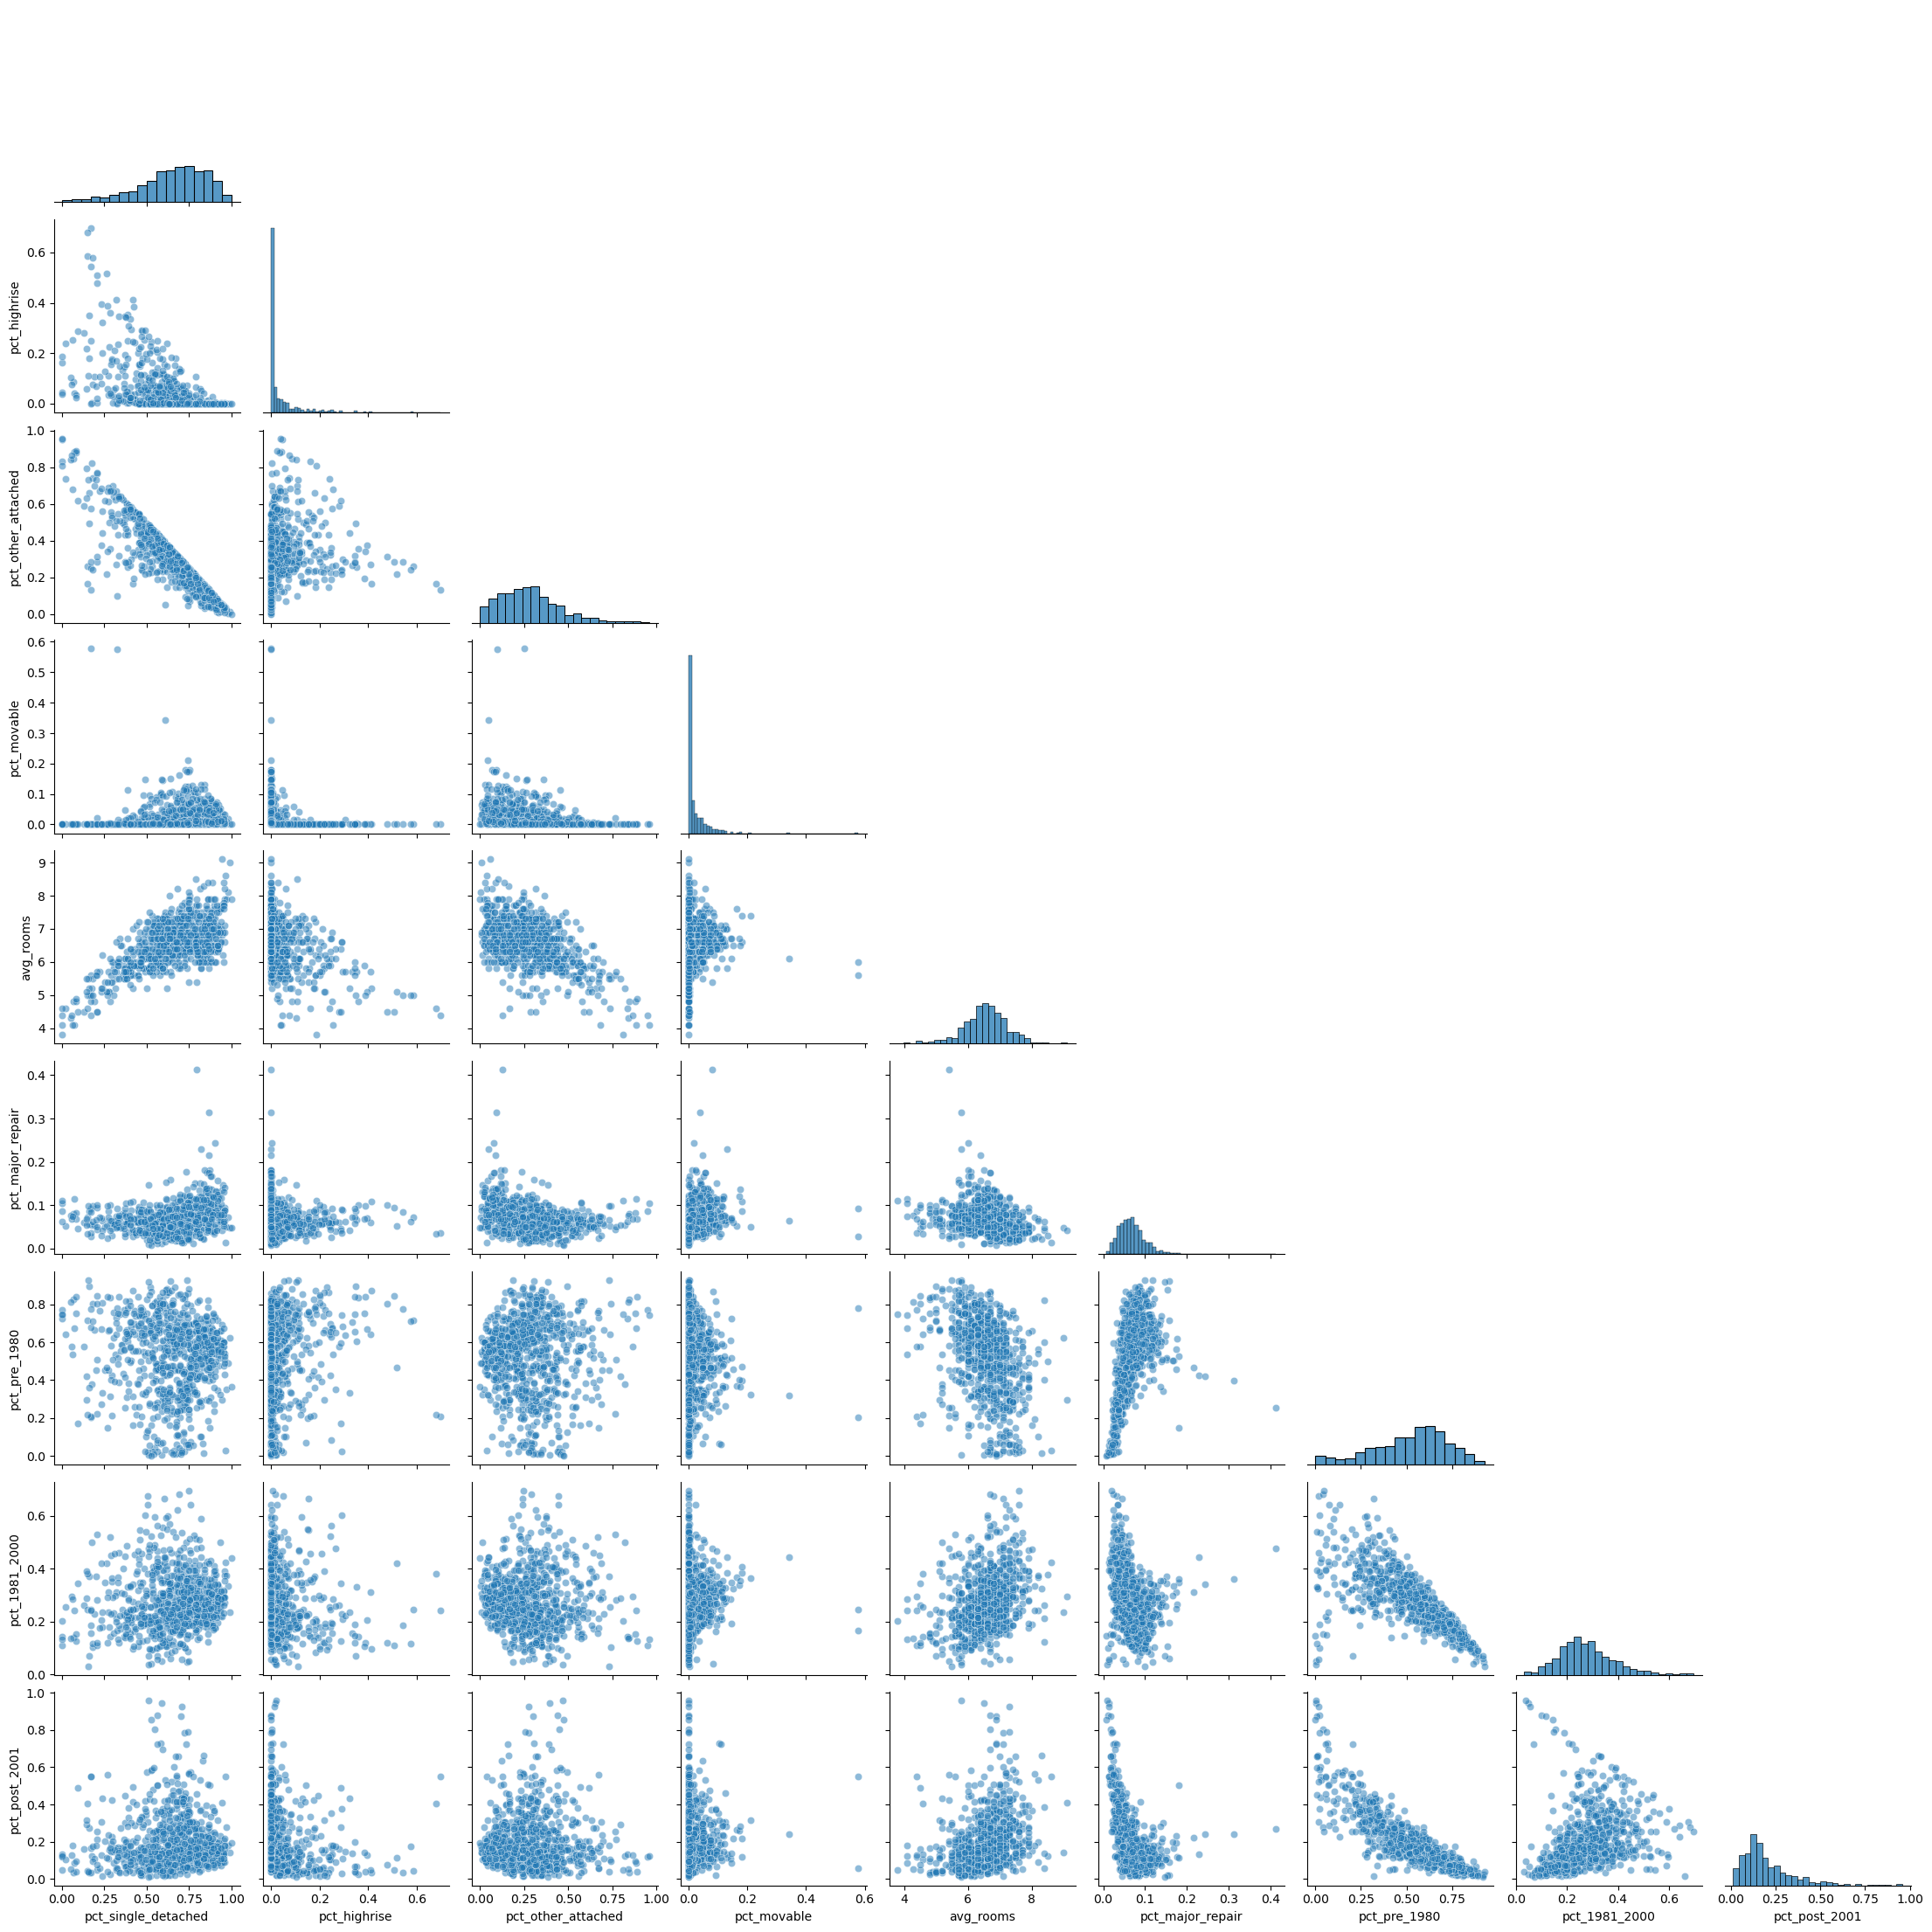

In [8]:

sample_df = df[structural_cols].drop_duplicates().sample(
    min(800, df["fsa"].nunique()), random_state=1
)

sns.pairplot(sample_df, corner=True, plot_kws={"alpha": 0.5})
plt.show()

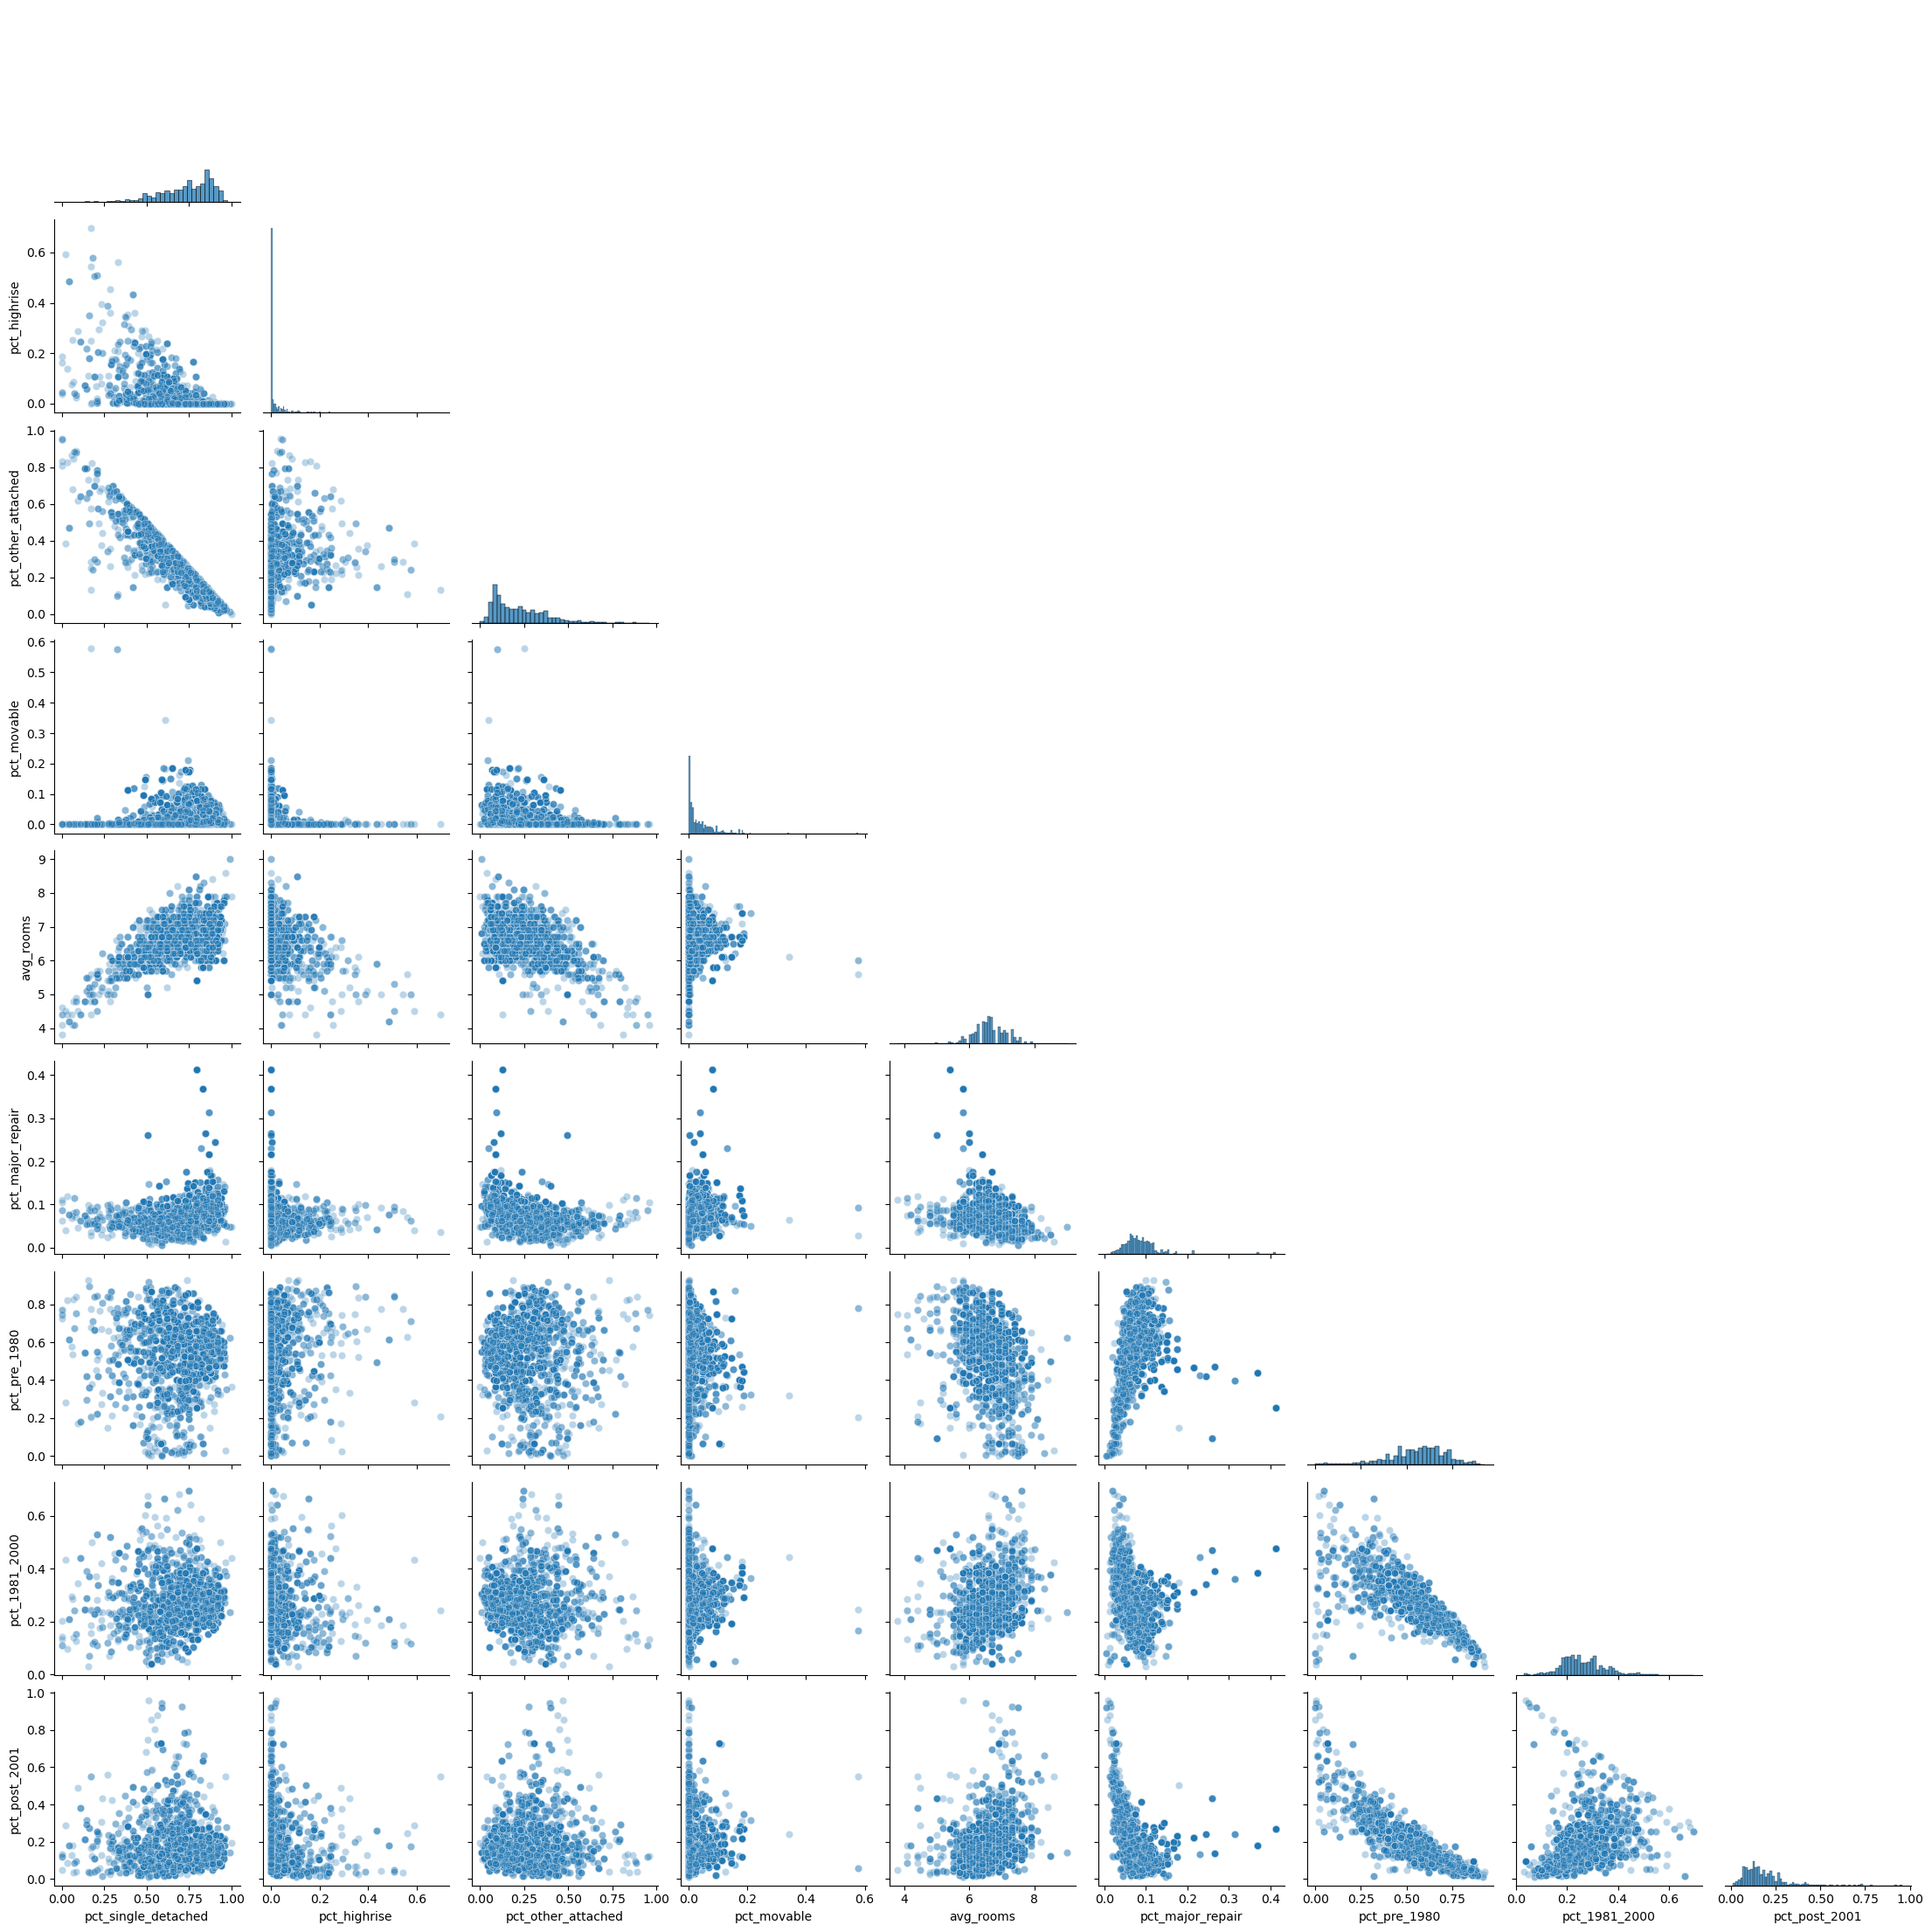

In [9]:

sns.pairplot(
    df[structural_cols].sample(5000, random_state=1),
    corner=True,
    plot_kws={"alpha": 0.3}
)

plt.show()

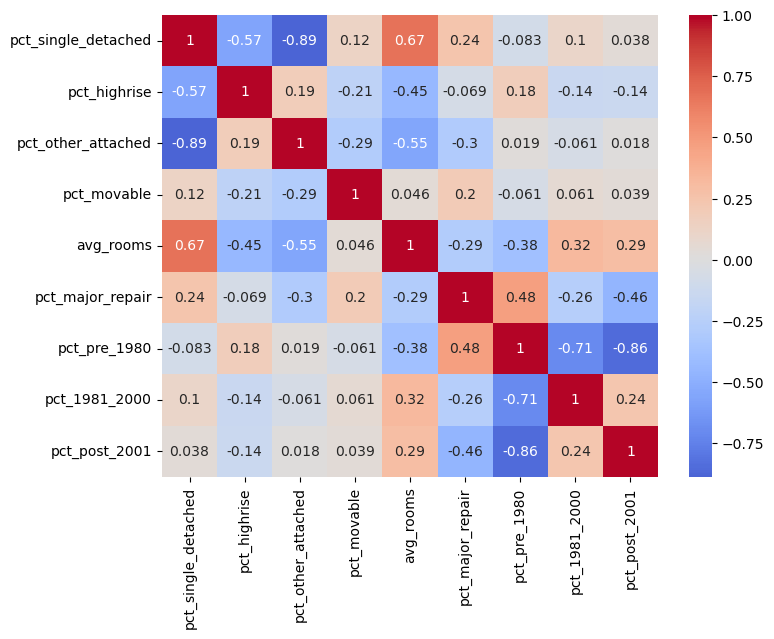

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(
    sample_df.corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.show()

In [20]:

X_struct = df[structural_cols]

X_scaled = StandardScaler().fit_transform(X_struct)

pca = PCA(n_components=3)
PCs = pca.fit_transform(X_scaled)

print(PCs)

df["PC1"] = PCs[:,0]
df["PC2"] = PCs[:,1]
df["PC3"] = PCs[:,2]

print(pca.explained_variance_ratio_)

[[ 1.45411434  0.36961717 -0.94548174]
 [ 1.45411434  0.36961717 -0.94548174]
 [ 1.01708069  1.48066854 -0.94019951]
 ...
 [ 1.86421614 -1.06121211  2.30221878]
 [ 1.86421614 -1.06121211  2.30221878]
 [ 1.86421614 -1.06121211  2.30221878]]
[0.3123243  0.26249897 0.16445485]


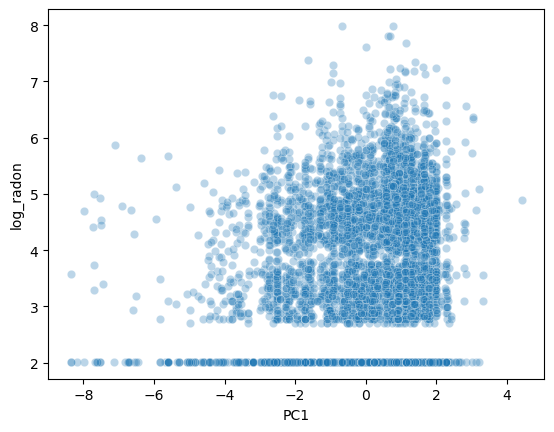

In [17]:
sns.scatterplot(
    data=df.sample(5000, random_state=1),
    x="PC1",
    y="log_radon",
    alpha=0.3
)
plt.show()